/tmp/ipykernel_94468/2264227936.py:4: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  train_labels = np.loadtxt('data/train_labels.txt', 'int') # incarcam etichetele avand
/tmp/ipykernel_94468/2264227936.py:6: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point

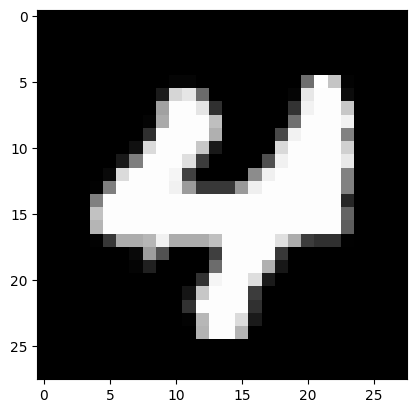

In [196]:
import numpy as np
import matplotlib.pyplot as plt
train_images = np.loadtxt('data/train_images.txt') # incarcam imaginile
train_labels = np.loadtxt('data/train_labels.txt', 'int') # incarcam etichetele avand
test_images = np.loadtxt('data/test_images.txt')
test_labels = np.loadtxt('data/test_labels.txt', 'int') # incarcam etichetele avand
# tipul de date int
image = train_images[0, :] # prima imagine
image = np.reshape(image, (28, 28))
plt.imshow(image.astype(np.uint8), cmap='gray')
plt.show()

## Ex 1

In [197]:
x = [(160, 'F'), (165, 'F'), (155, 'F'), (172, 'F'), (175, 'B'), (180, 'B'), (177, 'B'), (190, 'B')]
# bins = [150, 160, 170, 180, 190]
bins = np.linspace(150, 190, 5)

prob_b = len(list(filter(lambda x : x[1] == 'B', x))) / len(x)
prob_f = len(list(filter(lambda x : x[1] == 'F', x))) / len(x)

print(prob_b, prob_f)

x = map(lambda t : (np.digitize(t[0], bins, right=True), t[1]), x)
x = list(x)

0.5 0.5


In [198]:
x
bins

array([150., 160., 170., 180., 190.])

In [199]:
from collections import defaultdict
p_cond = defaultdict(float)

for L in ["F", "B"]:
    for idx in range(1, 5):
        total = len(list(filter(lambda t : t[1] == L, x)))
        favorable = len(list(filter(lambda t : t[0] == idx and t[1] == L, x)))
        p_cond[(idx, L)]  = favorable / total

p_cond


defaultdict(float,
            {(1, 'F'): 0.5,
             (2, 'F'): 0.25,
             (3, 'F'): 0.25,
             (4, 'F'): 0.0,
             (1, 'B'): 0.0,
             (2, 'B'): 0.0,
             (3, 'B'): 0.75,
             (4, 'B'): 0.25})

In [200]:
def predict(label, value):
    idx = np.digitize(value, bins, right=True)

    print(idx)
    prob_joint_f = prob_f * p_cond[(idx, 'F')]
    prob_joint_b = prob_b * p_cond[(idx, 'B')]

    prob_total = prob_joint_f + prob_joint_b

    if label == 'F':
        return prob_joint_f / prob_total
    else:
        return prob_joint_b / prob_total

print(predict('F', 178))
print(predict('B', 178))

3
0.25
3
0.75


In [ ]:
def value_to_edges(mat, bins):
    return np.digitize(mat, bins) - 1

num_bins = 5
bins = np.linspace(0, 255, num_bins)

train_images_2 = value_to_edges(train_images, bins)
test_images_2 = value_to_edges(test_images, bins)

print(bins)



[  0.  85. 170. 255.]


In [202]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(train_images_2, train_labels)
model.predict(test_images_2)
model.score(test_images_2, test_labels)

0.838

In [203]:
for n in [3, 5, 7, 9, 11]:
    bins = np.linspace(0, 255, n)
    train_images_2 = value_to_edges(train_images, bins)
    test_images_2 = value_to_edges(test_images, bins)
    model.fit(train_images_2, train_labels)
    model.predict(test_images_2)
    s = model.score(test_images_2, test_labels)
    print(s)

0.826
0.836
0.842
0.842
0.842


Actual 5, predicted 8


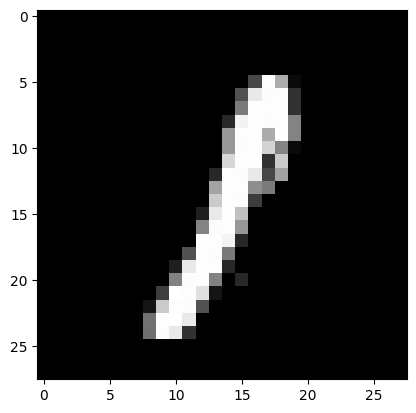

Actual 6, predicted 0


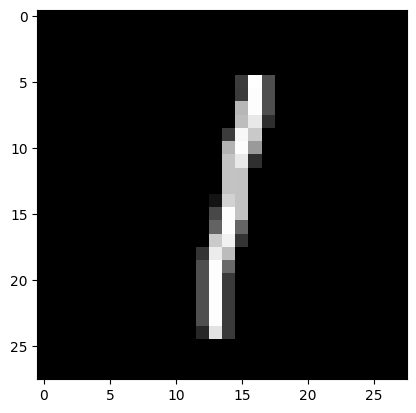

Actual 4, predicted 9


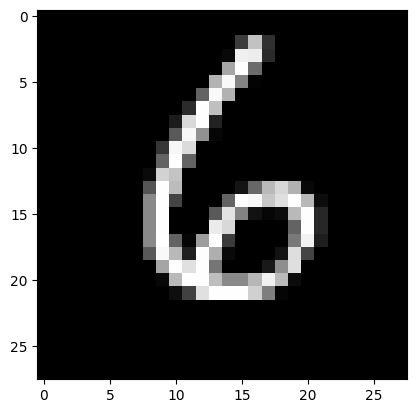

Actual 7, predicted 9


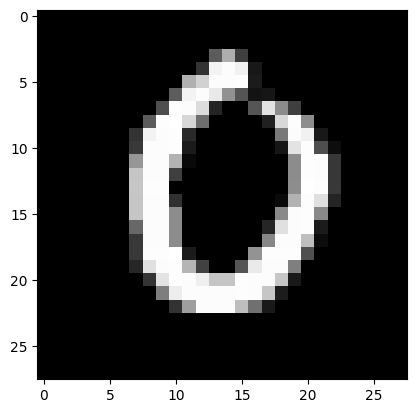

Actual 2, predicted 3


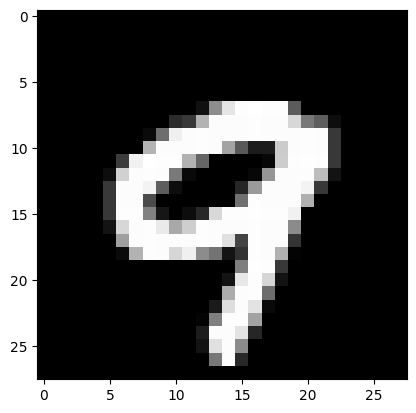

Actual 1, predicted 8


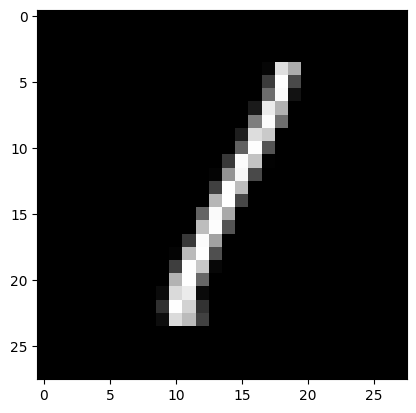

Actual 3, predicted 9


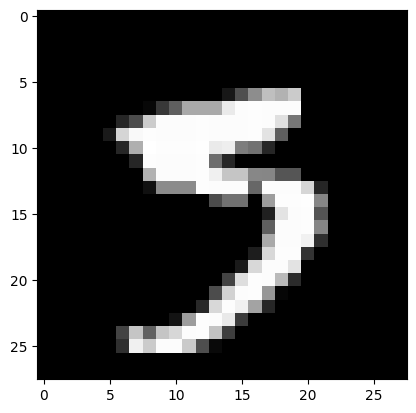

Actual 1, predicted 8


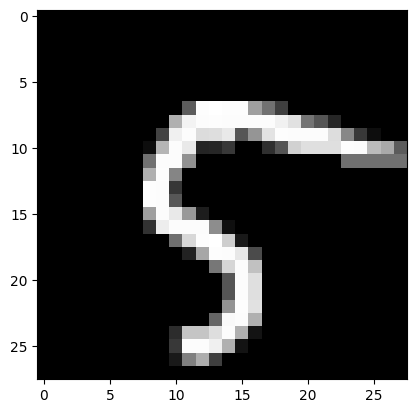

Actual 6, predicted 8


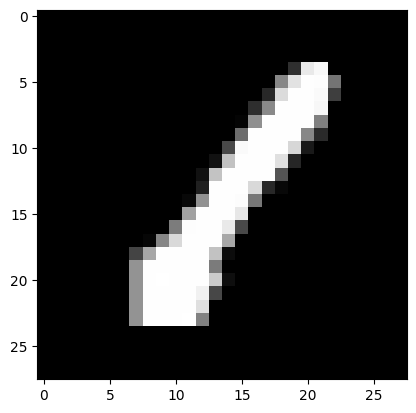

Actual 9, predicted 4


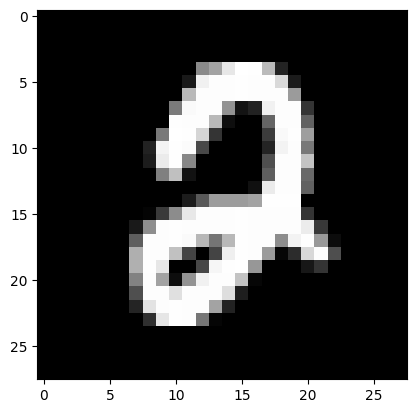

In [204]:
num_bins = 11
bins = np.linspace(0, 255, num_bins)
train_images_2 = value_to_edges(train_images, bins)
test_images_2 = value_to_edges(test_images, bins)
model.fit(train_images_2, train_labels)
predictions = model.predict(test_images_2)

miss_indices = np.where(predictions != test_labels)[0][:10]

for idx in miss_indices:
    image = train_images[idx, :] # prima imagine
    image = np.reshape(image, (28, 28))
    print(f"Actual {test_labels[idx]}, predicted {predictions[idx]}")
    plt.imshow(image.astype(np.uint8), cmap='gray')
    plt.show()